<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/ML_class3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/movies_dataset_realistic.csv")

In [ ]:
df

,movie_title,user_id,genres,watch_time,imdb_score,movie_likes
0,The Green Mile (926),User_4372,Fantasy,111,1.7,3726
1,Goodfellas (157),User_645,"Comedy, Fantasy",156,4.9,9711
2,Toy Story (1552),User_1314,"Horror, Animation, Fantasy",80,5.7,9443
3,Goodfellas (788),User_3724,"Comedy, Drama, Sci-Fi",76,5.4,5942
4,Whiplash (1480),User_4632,"Romance, Thriller, Fantasy",106,5.2,3849
...,...,...,...,...,...,...
19995,Avengers: Endgame (1804),User_4788,"Romance, Action",117,7.3,358
19996,The Matrix (1710),User_317,Horror,103,2.8,6288
19997,The Dark Knight (963),User_762,"Romance, Comedy",105,6.1,5775
19998,Whiplash (1737),User_986,"Fantasy, Horror, Comedy",25,6.6,9339


In [ ]:
df['movie_title'] = df['movie_title'].str.replace(r'\s*\(\d+\)$', '', regex=True)
df

,movie_title,user_id,genres,watch_time,imdb_score,movie_likes
0,The Green Mile,User_4372,Fantasy,111,1.7,3726
1,Goodfellas,User_645,"Comedy, Fantasy",156,4.9,9711
2,Toy Story,User_1314,"Horror, Animation, Fantasy",80,5.7,9443
3,Goodfellas,User_3724,"Comedy, Drama, Sci-Fi",76,5.4,5942
4,Whiplash,User_4632,"Romance, Thriller, Fantasy",106,5.2,3849
...,...,...,...,...,...,...
19995,Avengers: Endgame,User_4788,"Romance, Action",117,7.3,358
19996,The Matrix,User_317,Horror,103,2.8,6288
19997,The Dark Knight,User_762,"Romance, Comedy",105,6.1,5775
19998,Whiplash,User_986,"Fantasy, Horror, Comedy",25,6.6,9339


In [ ]:
df.drop(columns=['user_id'], inplace=True)
display(df.head())

,movie_title,genres,watch_time,imdb_score,movie_likes
0,The Green Mile,Fantasy,111,1.7,3726
1,Goodfellas,"Comedy, Fantasy",156,4.9,9711
2,Toy Story,"Horror, Animation, Fantasy",80,5.7,9443
3,Goodfellas,"Comedy, Drama, Sci-Fi",76,5.4,5942
4,Whiplash,"Romance, Thriller, Fantasy",106,5.2,3849


In [ ]:
null_counts = df.isnull().sum()
print("Null values per column:")
display(null_counts)

Null values per column:


,0
movie_title,0
genres,0
watch_time,0
imdb_score,0
movie_likes,0


In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# If there are duplicates, we can also see a few examples
if duplicate_count > 0:
    display(df[df.duplicated()].head())

Total duplicate rows: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   movie_title  20000 non-null  object 
 1   genres       20000 non-null  object 
 2   watch_time   20000 non-null  int64  
 3   imdb_score   20000 non-null  float64
 4   movie_likes  20000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 781.4+ KB


In [ ]:
movie_title_counts = df['movie_title'].value_counts().head(10)
print("Top 10 Most Frequent Movie Titles:")
display(movie_title_counts)

Top 10 Most Frequent Movie Titles:


,count
movie_title,
Gladiator,710
Whiplash,650
"Monsters, Inc.",649
The Dark Knight,647
Goodfellas,613
Avengers: Endgame,611
The Lord of the Rings: The Return of the King,605
Ratatouille,603
The Silence of the Lambs,573


In [ ]:
unique_movie_count = df['movie_title'].nunique()
print(f"Total unique movie titles: {unique_movie_count}")

Total unique movie titles: 38


In [ ]:
import pandas as pd
from collections import Counter

def get_top_3_genres(series):
    # Flatten all genres and count frequencies
    all_genres = [genre.strip() for sublist in series.str.split(',') for genre in sublist]
    counts = Counter(all_genres)
    # Get the top 3 most common
    top_3 = [item[0] for item in counts.most_common(3)]
    return ', '.join(top_3)

# Aggregate the data including the sum of likes
df = df.groupby('movie_title').agg({
    'genres': get_top_3_genres,
    'watch_time': lambda x: x.quantile(0.75),
    'imdb_score': lambda x: round(x.quantile(0.75), 1),
    'movie_likes': 'sum'
}).reset_index()

display(df)

,movie_title,genres,watch_time,imdb_score,movie_likes
0,Avengers: Endgame,"Animation, Horror, Sci-Fi",141.00,7.8,3049999
1,Back to the Future,"Sci-Fi, Animation, Comedy",134.00,7.9,2051137
2,Coco,"Thriller, Horror, Comedy",138.00,7.7,2628986
3,Fight Club,"Documentary, Animation, Action",142.00,7.3,2626993
4,Finding Nemo,"Action, Fantasy, Documentary",139.00,7.6,2602788
5,Forrest Gump,"Animation, Documentary, Thriller",132.25,7.6,2842734
6,Gladiator,"Fantasy, Romance, Thriller",139.00,7.9,3621137
7,Goodfellas,"Romance, Comedy, Documentary",138.00,7.5,3023628
8,Inception,"Drama, Sci-Fi, Action",137.00,7.9,2736045
9,Inside Out,"Thriller, Documentary, Sci-Fi",141.50,7.4,2446970


In [ ]:
numerical_summary = df[['imdb_score', 'watch_time', 'movie_likes']].describe()
print("Summary Statistics for Numerical Variables:")
display(numerical_summary)

Summary Statistics for Numerical Variables:


,imdb_score,watch_time,movie_likes
count,38.000000,38.000000,3.800000e+01
mean,7.689474,137.171053,2.627806e+06
std,0.184229,3.455365,4.035082e+05
min,7.300000,128.000000,1.522622e+06
25%,7.600000,136.000000,2.396300e+06
50%,7.700000,137.375000,2.627106e+06
75%,7.800000,139.000000,2.892218e+06
max,8.100000,144.000000,3.621137e+06


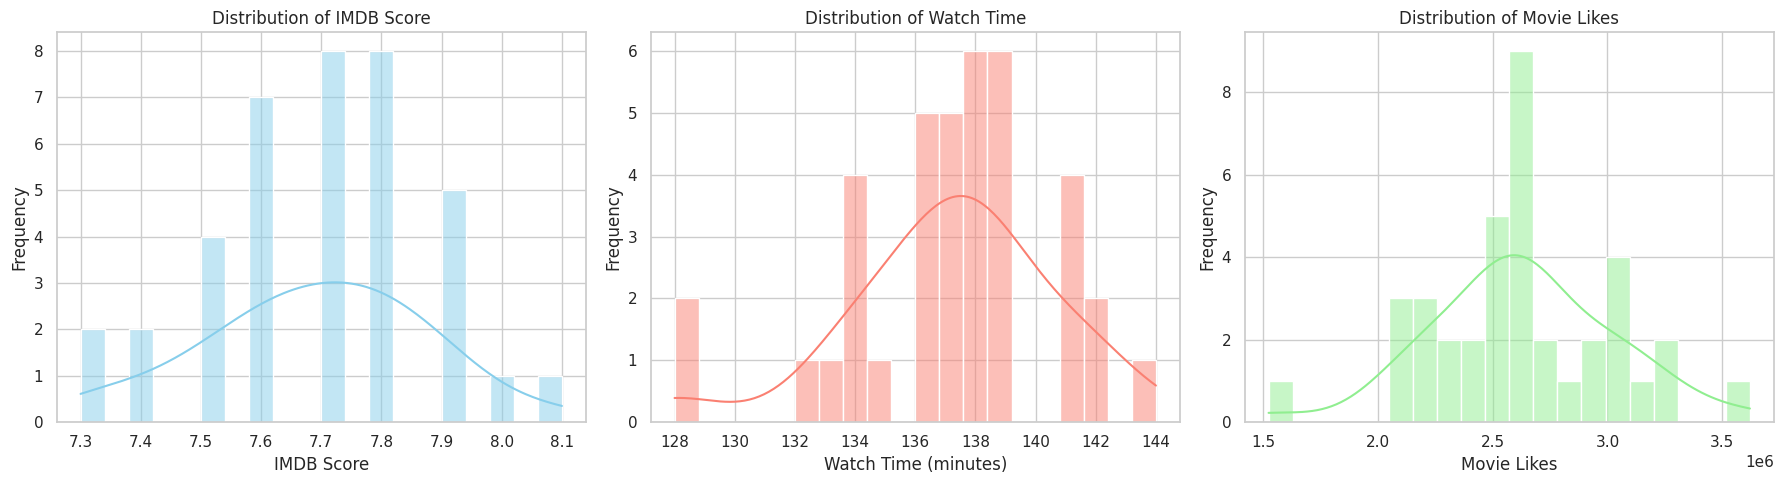

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot histogram for imdb_score
sns.histplot(df['imdb_score'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of IMDB Score')
axes[0].set_xlabel('IMDB Score')
axes[0].set_ylabel('Frequency')

# Plot histogram for watch_time
sns.histplot(df['watch_time'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Watch Time')
axes[1].set_xlabel('Watch Time (minutes)')
axes[1].set_ylabel('Frequency')

# Plot histogram for movie_likes
sns.histplot(df['movie_likes'], bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Movie Likes')
axes[2].set_xlabel('Movie Likes')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

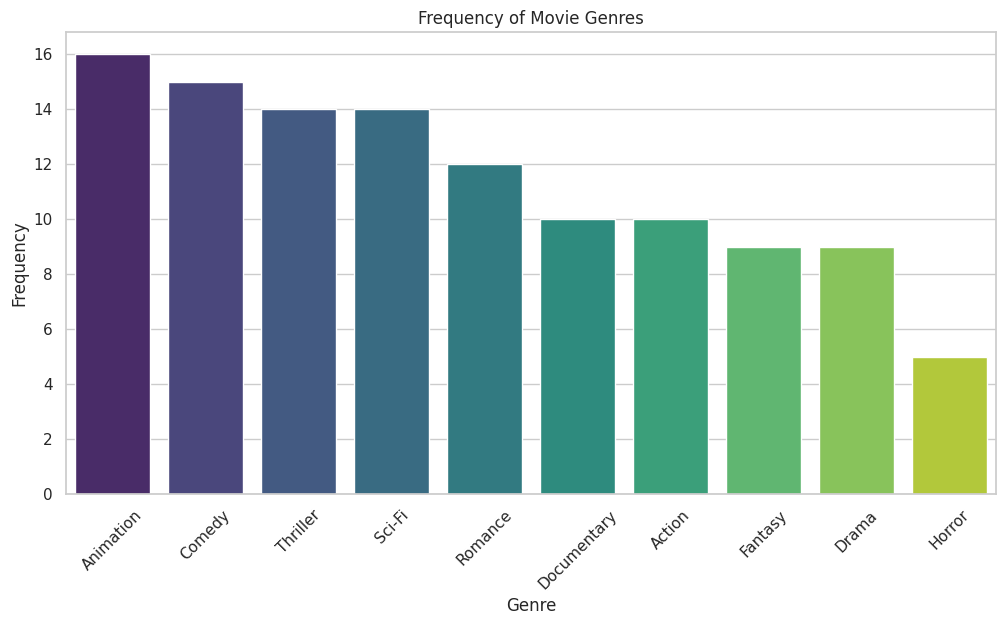

Genre Counts:
genres
Animation      16
Comedy         15
Thriller       14
Sci-Fi         14
Romance        12
Documentary    10
Action         10
Fantasy         9
Drama           9
Horror          5
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Split the 'genres' column and explode to get individual genre counts
genres_series = df['genres'].str.split(', ').explode()
genre_counts = genres_series.value_counts()

# Visualize the top genres using a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='viridis', legend=False)
plt.title('Frequency of Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

print("Genre Counts:")
print(genre_counts)

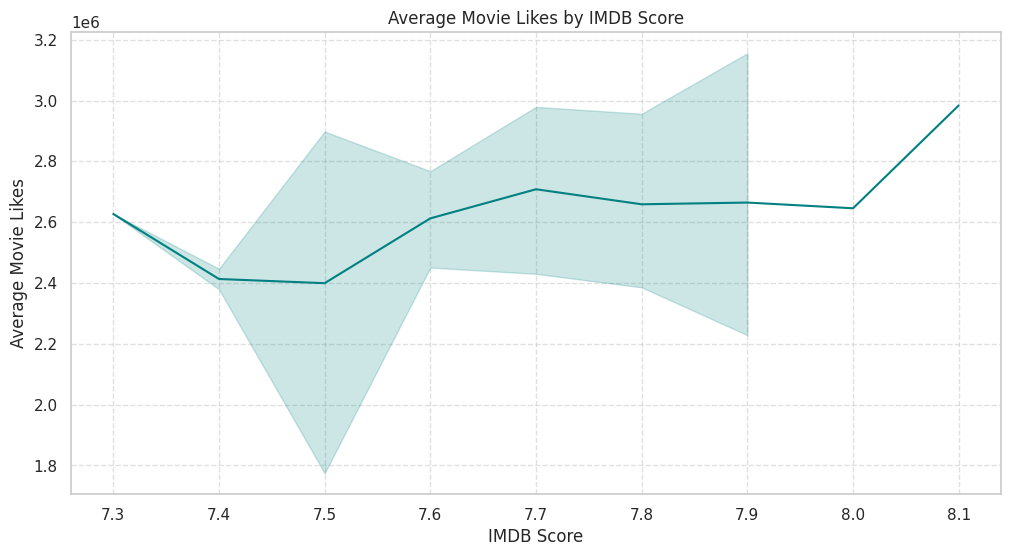

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a line plot to see the trend of likes across IMDB scores
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='imdb_score', y='movie_likes', color='teal')
plt.title('Average Movie Likes by IMDB Score')
plt.xlabel('IMDB Score')
plt.ylabel('Average Movie Likes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

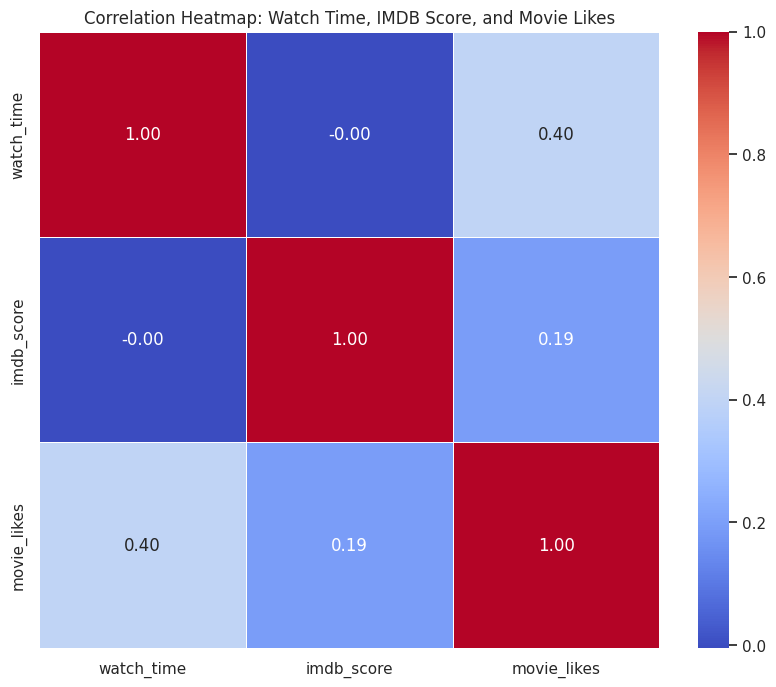

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df[['watch_time', 'imdb_score', 'movie_likes']].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Watch Time, IMDB Score, and Movie Likes')
plt.show()

In [ ]:
from statsmodels.stats.weightstats import ztest

# Performing a one-sample z-test
# Null Hypothesis (H0): The mean IMDB score is 7.5
# Alternative Hypothesis (H1): The mean IMDB score is not 7.5
hypothesized_mean = 7.5

z_stat, p_value = ztest(df['imdb_score'], value=hypothesized_mean)

print(f"One-sample Z-test Results for IMDB Score (Comparing to mean of {hypothesized_mean}):")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis. There is a significant difference.")
else:
    print("\nResult: Fail to reject the Null Hypothesis. No significant difference found.")

One-sample Z-test Results for IMDB Score (Comparing to mean of 7.5):
Z-statistic: 6.3399
P-value: 0.0000

Result: Reject the Null Hypothesis. There is a significant difference.


In [ ]:
df['primary_genre'] = df['genres'].str.split(',').str[0].str.strip()
display(df.head())

,movie_title,genres,watch_time,imdb_score,movie_likes,primary_genre
0,Avengers: Endgame,"Animation, Horror, Sci-Fi",141.0,7.8,3049999,Animation
1,Back to the Future,"Sci-Fi, Animation, Comedy",134.0,7.9,2051137,Sci-Fi
2,Coco,"Thriller, Horror, Comedy",138.0,7.7,2628986,Thriller
3,Fight Club,"Documentary, Animation, Action",142.0,7.3,2626993,Documentary
4,Finding Nemo,"Action, Fantasy, Documentary",139.0,7.6,2602788,Action


In [ ]:
from scipy.stats import ttest_ind

# Filter the imdb_scores for 'Animation' and 'Action' genres
animation_scores = df[df['primary_genre'] == 'Animation']['imdb_score']
action_scores = df[df['primary_genre'] == 'Action']['imdb_score']

# Perform the independent T-test
t_stat, p_val = ttest_ind(animation_scores, action_scores)

print(f"Independent T-test Results (Animation vs. Action):")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Interpretation
alpha = 0.05
if p_val < alpha:
    print("\nResult: Reject the Null Hypothesis. There is a significant difference in mean IMDB scores.")
else:
    print("\nResult: Fail to reject the Null Hypothesis. No significant difference in mean IMDB scores found.")

Independent T-test Results (Animation vs. Action):
T-statistic: -0.3007
P-value: 0.7724

Result: Fail to reject the Null Hypothesis. No significant difference in mean IMDB scores found.


In [ ]:
from scipy.stats import f_oneway

# Filter the watch_time for 'Animation', 'Comedy', and 'Thriller' genres
animation_watch_time = df[df['primary_genre'] == 'Animation']['watch_time']
comedy_watch_time = df[df['primary_genre'] == 'Comedy']['watch_time']
thriller_watch_time = df[df['primary_genre'] == 'Thriller']['watch_time']

# Perform the One-Way ANOVA test
f_stat, p_val_anova = f_oneway(animation_watch_time, comedy_watch_time, thriller_watch_time)

print(f"One-Way ANOVA Results (Animation vs. Comedy vs. Thriller):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.4f}")

# Interpretation
alpha = 0.05
if p_val_anova < alpha:
    print("\nResult: Reject the Null Hypothesis. There is a significant difference in mean watch time across genres.")
else:
    print("\nResult: Fail to reject the Null Hypothesis. No significant difference in mean watch time across genres found.")

One-Way ANOVA Results (Animation vs. Comedy vs. Thriller):
F-statistic: 0.6485
P-value: 0.5417

Result: Fail to reject the Null Hypothesis. No significant difference in mean watch time across genres found.


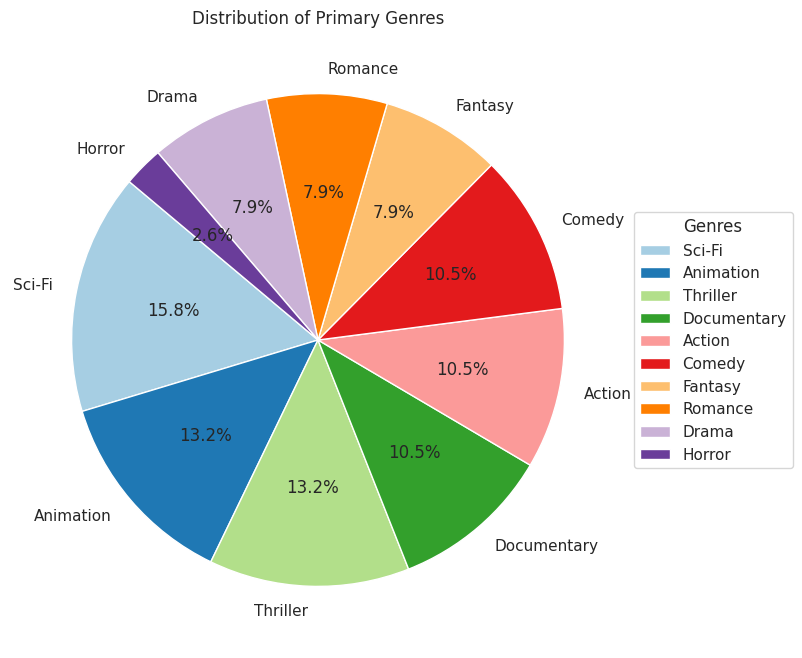

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the frequency of each genre in the 'primary_genre' column
primary_genre_counts = df['primary_genre'].value_counts()

# 2. Create a pie chart using plt.pie()
plt.figure(figsize=(10, 8))
plt.pie(
    primary_genre_counts,
    labels=primary_genre_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired(range(len(primary_genre_counts)))
)

# 5. Add a legend and title
plt.legend(primary_genre_counts.index, title="Genres", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Distribution of Primary Genres')

# 6. Display the pie chart
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# 1. One-Hot Encoding for 'genres' after splitting by comma
genres_encoded = df['genres'].str.get_dummies(sep=', ')

# 2. Label Encoding for 'movie_title'
le = LabelEncoder()
df['movie_title_encoded'] = le.fit_transform(df['movie_title'])

# 3. Standard Scaling for numerical features
scaler = StandardScaler()
numerical_cols = ['watch_time', 'imdb_score', 'movie_likes']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Combine the encoded genres with the rest of the dataframe
df_preprocessed = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)

# Display the first few rows of the preprocessed dataset
display(df_preprocessed.head())

,movie_title,watch_time,imdb_score,movie_likes,primary_genre,movie_title_encoded,Action,Animation,Comedy,Documentary,Drama,Fantasy,Horror,Romance,Sci-Fi,Thriller
0,Avengers: Endgame,1.122991,0.607994,1.060352,Animation,0,0,1,0,0,0,0,1,0,1,0
1,Back to the Future,-0.930038,1.158083,-1.448321,Sci-Fi,1,0,1,1,0,0,0,0,0,1,0
2,Coco,0.243122,0.057904,0.002965,Thriller,2,0,0,1,0,0,0,1,0,0,1
3,Fight Club,1.416281,-2.142454,-0.002041,Documentary,3,1,1,0,1,0,0,0,0,0,0
4,Finding Nemo,0.536412,-0.492185,-0.062832,Action,4,1,0,0,1,0,1,0,0,0,0


In [ ]:
# Drop the original categorical columns
df_final = df_preprocessed.drop(columns=['movie_title', 'primary_genre'])

# Display the final numerical dataset
display(df_final.head())

,watch_time,imdb_score,movie_likes,movie_title_encoded,Action,Animation,Comedy,Documentary,Drama,Fantasy,Horror,Romance,Sci-Fi,Thriller
0,1.122991,0.607994,1.060352,0,0,1,0,0,0,0,1,0,1,0
1,-0.930038,1.158083,-1.448321,1,0,1,1,0,0,0,0,0,1,0
2,0.243122,0.057904,0.002965,2,0,0,1,0,0,0,1,0,0,1
3,1.416281,-2.142454,-0.002041,3,1,1,0,1,0,0,0,0,0,0
4,0.536412,-0.492185,-0.062832,4,1,0,0,1,0,1,0,0,0,0
